


Apriori, os exemplos comuns:

- Prateleiras de mercados

Final de semana, homens em dia de jogo, compra de fraldas e cervejas. (produtos próximos)

produtos que parecem não ter relações, mas dependendo do dia tem.


- Promoções com itens que são vendidos em conjunto.

- Planejar catálogos das lojas e folhetos de promoções.

Semelhantes a prateleiras, ao exemplo dos mercados

- pizzaria

regra euleritica, chove e aumento o pedido de pizza à noite.

Regra de associação.

- Controle de evasão em universidades

- Sistemas de recomendação de filmes e produtos

- Análise de cestas de compras (market Basket Analysis)

# 20.3) Apriori Suporte

In [100]:
import pandas as pd

dados = {
    1: {
        "leite": "não",
        "café": "sim",
        "cerveja": "não",
        "pão": "sim",
        "manteiga": "sim",
        "arroz": "não",
        "feijão": "não"
    },
    2: {
        "leite": "sim",
        "café": "não",
        "cerveja": "sim",
        "pão": "sim",
        "manteiga": "sim",
        "arroz": "não",
        "feijão": "não"
    },
    3: {
        "leite": "não",
        "café": "sim",
        "cerveja": "não",
        "pão": "sim",
        "manteiga": "sim",
        "arroz": "não",
        "feijão": "não"
    },
    4: {
        "leite": "sim",
        "café": "sim",
        "cerveja": "não",
        "pão": "sim",
        "manteiga": "sim",
        "arroz": "não",
        "feijão": "não"
    }  ,  
    5: {
        "leite": "não",
        "café": "não",
        "cerveja": "sim",
        "pão": "não",
        "manteiga": "não",
        "arroz": "não",
        "feijão": "não"
    }  ,          
    6: {
        "leite": "não",
        "café": "não",
        "cerveja": "não",
        "pão": "não",
        "manteiga": "sim",
        "arroz": "não",
        "feijão": "não"
    }  ,     
    7: {
        "leite": "não",
        "café": "não",
        "cerveja": "não",
        "pão": "sim",
        "manteiga": "não",
        "arroz": "não",
        "feijão": "não"
    }  ,     
    8: {
        "leite": "não",
        "café": "não",
        "cerveja": "não",
        "pão": "não",
        "manteiga": "não",
        "arroz": "não",
        "feijão": "sim"
    }  ,           
    9: {
        "leite": "não",
        "café": "não",
        "cerveja": "não",
        "pão": "não",
        "manteiga": "não",
        "arroz": "sim",
        "feijão": "sim"
    }  ,  
    10: {
        "leite": "não",
        "café": "não",
        "cerveja": "não",
        "pão": "não",
        "manteiga": "não",
        "arroz": "sim",
        "feijão": "não"
    }  ,             
           
}

In [101]:
df_dados = pd.DataFrame(dados)


In [102]:
df_dados

,1,2,3,4,5,6,7,8,9,10
leite,não,sim,não,sim,não,não,não,não,não,não
café,sim,não,sim,sim,não,não,não,não,não,não
cerveja,não,sim,não,não,sim,não,não,não,não,não
pão,sim,sim,sim,sim,não,não,sim,não,não,não
manteiga,sim,sim,sim,sim,não,sim,não,não,não,não
arroz,não,não,não,não,não,não,não,não,sim,sim
feijão,não,não,não,não,não,não,não,sim,sim,não


In [103]:
df_transposto = df_dados.T
print("\n Tabela Transposto:")
display(df_transposto)


 Tabela Transposto:


,leite,café,cerveja,pão,manteiga,arroz,feijão
1,não,sim,não,sim,sim,não,não
2,sim,não,sim,sim,sim,não,não
3,não,sim,não,sim,sim,não,não
4,sim,sim,não,sim,sim,não,não
5,não,não,sim,não,não,não,não
6,não,não,não,não,sim,não,não
7,não,não,não,sim,não,não,não
8,não,não,não,não,não,não,sim
9,não,não,não,não,não,sim,sim
10,não,não,não,não,não,sim,não


Suporte = Número de registros com X e Y / Número total de registros 

Fase 1) Descobrir todos os conjuntos de itens com suporte maior ou igual ao mínimo especificado pelo usuário. 

In [104]:
colunas = list(df_transposto.columns)

In [105]:
len(df_transposto.loc[df_transposto['leite']=='sim'])

2

In [106]:
len(df_transposto)

10

In [107]:
for col in colunas:
    suporte = len(df_transposto.loc[df_transposto[col]=='sim'])/len(df_transposto)
    Aparecer = len(df_transposto.loc[df_transposto[col]=='sim'])
    print(f'{col} aparece nas compras {Aparecer} vezes')
    print(f'suporte para o {col}: {suporte*100} %')
    print()

leite aparece nas compras 2 vezes
suporte para o leite: 20.0 %

café aparece nas compras 3 vezes
suporte para o café: 30.0 %

cerveja aparece nas compras 2 vezes
suporte para o cerveja: 20.0 %

pão aparece nas compras 5 vezes
suporte para o pão: 50.0 %

manteiga aparece nas compras 5 vezes
suporte para o manteiga: 50.0 %

arroz aparece nas compras 2 vezes
suporte para o arroz: 20.0 %

feijão aparece nas compras 2 vezes
suporte para o feijão: 20.0 %



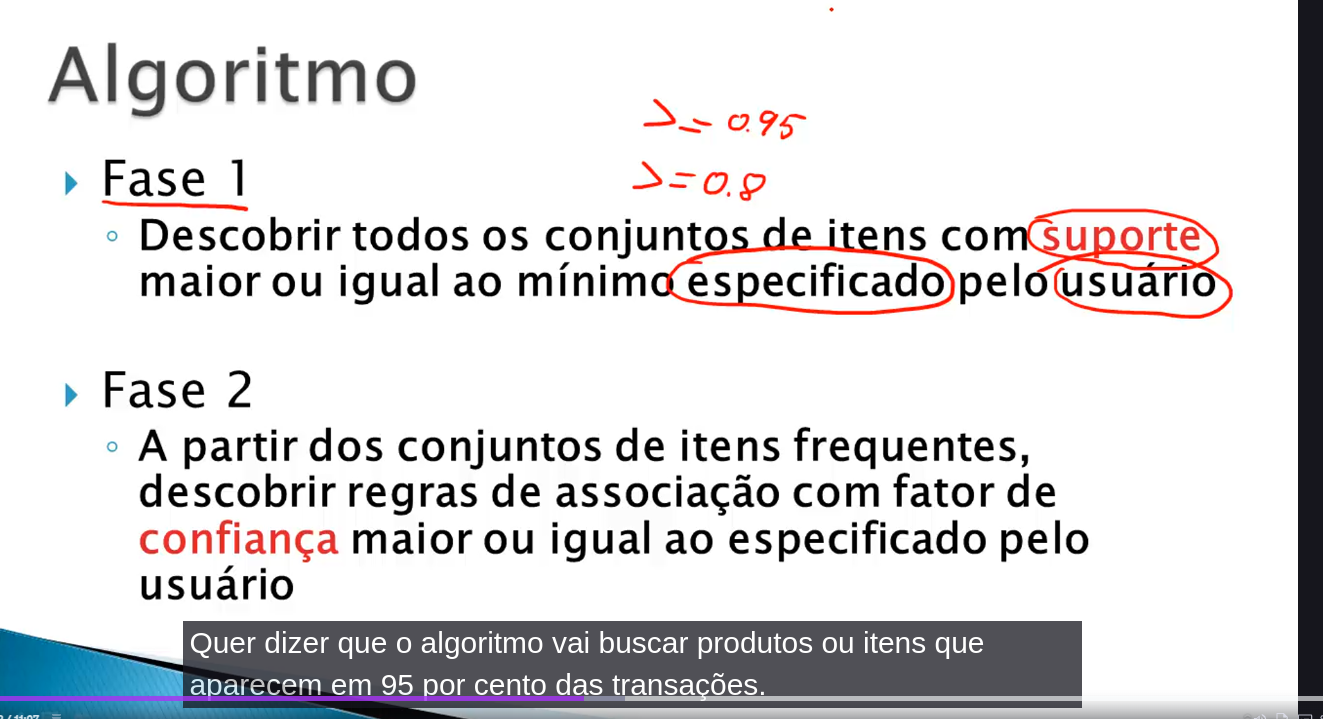

cálculo do suporte para gerar regras. 

* vamos definir suporte >=0,3,

não vamos gerar regras para valores menores que 0,3 de suporte, apenas será gerados regras para valores iguais ou acima de 0,3.

### 2) Calcular o suporte de conjuntos com 1 item (itemsets)

In [108]:
for col in colunas:
    suporte = len(df_transposto.loc[df_transposto[col]=='sim'])/len(df_transposto)
    Aparecer = len(df_transposto.loc[df_transposto[col]=='sim'])
    if suporte>=0.3:
        print(f'{col} aparece nas compras {Aparecer} vezes')
        print(f'suporte para o {col}: {suporte*100} %')
        print()

café aparece nas compras 3 vezes
suporte para o café: 30.0 %

pão aparece nas compras 5 vezes
suporte para o pão: 50.0 %

manteiga aparece nas compras 5 vezes
suporte para o manteiga: 50.0 %



* calcular o suporte de conjuntos de 2 itens

Fazer combinações com vários itens, itemsets

In [109]:
for col1 in colunas:
    for col2 in colunas:
        if col1 != col2:
           print(f'{col1} e {col2}')

leite e café
leite e cerveja
leite e pão
leite e manteiga
leite e arroz
leite e feijão
café e leite
café e cerveja
café e pão
café e manteiga
café e arroz
café e feijão
cerveja e leite
cerveja e café
cerveja e pão
cerveja e manteiga
cerveja e arroz
cerveja e feijão
pão e leite
pão e café
pão e cerveja
pão e manteiga
pão e arroz
pão e feijão
manteiga e leite
manteiga e café
manteiga e cerveja
manteiga e pão
manteiga e arroz
manteiga e feijão
arroz e leite
arroz e café
arroz e cerveja
arroz e pão
arroz e manteiga
arroz e feijão
feijão e leite
feijão e café
feijão e cerveja
feijão e pão
feijão e manteiga
feijão e arroz


In [110]:
# o quanto são vendidos em conjuntos os produtos:
from itertools import combinations

for col1, col2 in combinations(colunas, 2):
    print(f'{col1} e {col2}')

leite e café
leite e cerveja
leite e pão
leite e manteiga
leite e arroz
leite e feijão
café e cerveja
café e pão
café e manteiga
café e arroz
café e feijão
cerveja e pão
cerveja e manteiga
cerveja e arroz
cerveja e feijão
pão e manteiga
pão e arroz
pão e feijão
manteiga e arroz
manteiga e feijão
arroz e feijão


In [111]:
# o quanto são vendidos em conjuntos os produtos:
from itertools import combinations

for col1, col2 in combinations(colunas, 2):
    print(f'{col1} e {col2}')
    suporte = len(df_transposto.loc[ (df_transposto[col1]=='sim') & (df_transposto[col2]=='sim') ] )/len(df_transposto)
    Aparecer = len(df_transposto.loc[(df_transposto[col1]=='sim') & (df_transposto[col2]=='sim') ])
    print(f'{col1} e {col2} aparecem nas compras {Aparecer} vezes')
    print(f'suporte para o {col1} e {col2}: {suporte*100} %')
    print()


leite e café
leite e café aparecem nas compras 1 vezes
suporte para o leite e café: 10.0 %

leite e cerveja
leite e cerveja aparecem nas compras 1 vezes
suporte para o leite e cerveja: 10.0 %

leite e pão
leite e pão aparecem nas compras 2 vezes
suporte para o leite e pão: 20.0 %

leite e manteiga
leite e manteiga aparecem nas compras 2 vezes
suporte para o leite e manteiga: 20.0 %

leite e arroz
leite e arroz aparecem nas compras 0 vezes
suporte para o leite e arroz: 0.0 %

leite e feijão
leite e feijão aparecem nas compras 0 vezes
suporte para o leite e feijão: 0.0 %

café e cerveja
café e cerveja aparecem nas compras 0 vezes
suporte para o café e cerveja: 0.0 %

café e pão
café e pão aparecem nas compras 3 vezes
suporte para o café e pão: 30.0 %

café e manteiga
café e manteiga aparecem nas compras 3 vezes
suporte para o café e manteiga: 30.0 %

café e arroz
café e arroz aparecem nas compras 0 vezes
suporte para o café e arroz: 0.0 %

café e feijão
café e feijão aparecem nas compras

In [112]:
# o quanto são vendidos em conjuntos os produtos:
from itertools import combinations

for col1, col2 in combinations(colunas, 2):
    #print(f'{col1} e {col2}')
    suporte = len(df_transposto.loc[ (df_transposto[col1]=='sim') & (df_transposto[col2]=='sim') ] )/len(df_transposto)
    Aparecer = len(df_transposto.loc[(df_transposto[col1]=='sim') & (df_transposto[col2]=='sim') ])
    if 0.0 < Aparecer:
        print(f'{col1} e {col2} aparecem nas compras {Aparecer} vezes')
        print(f'suporte para o {col1} e {col2}: {suporte*100} %')
        print()


leite e café aparecem nas compras 1 vezes
suporte para o leite e café: 10.0 %

leite e cerveja aparecem nas compras 1 vezes
suporte para o leite e cerveja: 10.0 %

leite e pão aparecem nas compras 2 vezes
suporte para o leite e pão: 20.0 %

leite e manteiga aparecem nas compras 2 vezes
suporte para o leite e manteiga: 20.0 %

café e pão aparecem nas compras 3 vezes
suporte para o café e pão: 30.0 %

café e manteiga aparecem nas compras 3 vezes
suporte para o café e manteiga: 30.0 %

cerveja e pão aparecem nas compras 1 vezes
suporte para o cerveja e pão: 10.0 %

cerveja e manteiga aparecem nas compras 1 vezes
suporte para o cerveja e manteiga: 10.0 %

pão e manteiga aparecem nas compras 4 vezes
suporte para o pão e manteiga: 40.0 %

arroz e feijão aparecem nas compras 1 vezes
suporte para o arroz e feijão: 10.0 %



# forma correta do itemset

In [113]:
# o quanto são vendidos em conjuntos os produtos de forma correta pelo suporte:
from itertools import combinations

for col1, col2 in combinations(colunas, 2):
    #print(f'{col1} e {col2}')
    suporte = len(df_transposto.loc[ (df_transposto[col1]=='sim') & (df_transposto[col2]=='sim') ] )/len(df_transposto)
    Aparecer = len(df_transposto.loc[(df_transposto[col1]=='sim') & (df_transposto[col2]=='sim') ])
    if 0.0 < Aparecer and suporte >=0.3:
        print(f'itemset: {col1} e {col2} aparecem nas compras {Aparecer} vezes')
        print(f'suporte para o {col1} e {col2}: {suporte*100} %')
        print()

itemset: café e pão aparecem nas compras 3 vezes
suporte para o café e pão: 30.0 %

itemset: café e manteiga aparecem nas compras 3 vezes
suporte para o café e manteiga: 30.0 %

itemset: pão e manteiga aparecem nas compras 4 vezes
suporte para o pão e manteiga: 40.0 %



## 3) Calcular o suporte de conjuntos com 3 itens, e depois fazer isso sucetivamente. 

In [114]:
# o quanto são vendidos em conjuntos os produtos de forma correta pelo suporte:
from itertools import combinations

for col1, col2,col3 in combinations(colunas, 3):
    print()
    print(f'{col1}, {col2} e {col3}')
    suporte = len(df_transposto.loc[ (df_transposto[col1]=='sim') & (df_transposto[col2]=='sim') & (df_transposto[col3]=='sim') ] )/len(df_transposto)
    Aparecer = len(df_transposto.loc[(df_transposto[col1]=='sim') & (df_transposto[col2]=='sim')& (df_transposto[col3]=='sim') ])
    if 0.0 < Aparecer and suporte >=0.3:
       print(f'itemset: {col1}, {col2} e {col3} aparecem nas compras {Aparecer} vezes')
       print(f'suporte para o {col1}, {col2} e {col3}: {suporte*100} %')
       print()


leite, café e cerveja

leite, café e pão

leite, café e manteiga

leite, café e arroz

leite, café e feijão

leite, cerveja e pão

leite, cerveja e manteiga

leite, cerveja e arroz

leite, cerveja e feijão

leite, pão e manteiga

leite, pão e arroz

leite, pão e feijão

leite, manteiga e arroz

leite, manteiga e feijão

leite, arroz e feijão

café, cerveja e pão

café, cerveja e manteiga

café, cerveja e arroz

café, cerveja e feijão

café, pão e manteiga
itemset: café, pão e manteiga aparecem nas compras 3 vezes
suporte para o café, pão e manteiga: 30.0 %


café, pão e arroz

café, pão e feijão

café, manteiga e arroz

café, manteiga e feijão

café, arroz e feijão

cerveja, pão e manteiga

cerveja, pão e arroz

cerveja, pão e feijão

cerveja, manteiga e arroz

cerveja, manteiga e feijão

cerveja, arroz e feijão

pão, manteiga e arroz

pão, manteiga e feijão

pão, arroz e feijão

manteiga, arroz e feijão


# Descoberta dos suportes 

In [115]:
# o quanto são vendidos em conjuntos os produtos de forma correta pelo suporte:
from itertools import combinations
# suporte de 3 itens no exemplo
print('Suporte = Número de registros com X e Y / Número total de registros')
for col1, col2,col3 in combinations(colunas, 3):
    #print()
    #print(f'{col1}, {col2} e {col3}')
    suporte = len(df_transposto.loc[ (df_transposto[col1]=='sim') & (df_transposto[col2]=='sim') & (df_transposto[col3]=='sim') ] )/len(df_transposto)
    Aparecer = len(df_transposto.loc[(df_transposto[col1]=='sim') & (df_transposto[col2]=='sim')& (df_transposto[col3]=='sim') ])
    if 0.0 < Aparecer and suporte >=0.3:
       print(f'itemset: {col1}, {col2} e {col3} aparecem nas compras {Aparecer} vezes')
       print(f'suporte para o {col1}, {col2} e {col3}: {suporte*100} %')
       print()

Suporte = Número de registros com X e Y / Número total de registros
itemset: café, pão e manteiga aparecem nas compras 3 vezes
suporte para o café, pão e manteiga: 30.0 %



Com isso fazer as gerações das regras. 

# 20.4) Apriori Confiança

Fase 2) a partir dos conjuntos de itens frequentes, descobrir regras de associação com fator de <b> confiança</b> maior ou igual ao especificado pelo usuário. 

Fazer o valor de confiança das regras, mínimo das regras. 

### Confiança = Número de registros com X e Y (no exemplo é item 7) / número total de registros com X

In [116]:
display(df_transposto)

,leite,café,cerveja,pão,manteiga,arroz,feijão
1,não,sim,não,sim,sim,não,não
2,sim,não,sim,sim,sim,não,não
3,não,sim,não,sim,sim,não,não
4,sim,sim,não,sim,sim,não,não
5,não,não,sim,não,não,não,não
6,não,não,não,não,sim,não,não
7,não,não,não,sim,não,não,não
8,não,não,não,não,não,não,sim
9,não,não,não,não,não,sim,sim
10,não,não,não,não,não,sim,não


Definir um valor de confiança >= 0,8 ou 80%. 

usamos itemsets a partir de 2, o ideal.

há diferença entre SE café ENTÃO pão 

com 

SE pão ENTÃO café 

In [117]:
# teste de confiança
from itertools import combinations

for col1, col2 in combinations(colunas, 2):
    print(f'{col1} e {col2} ')

leite e café 
leite e cerveja 
leite e pão 
leite e manteiga 
leite e arroz 
leite e feijão 
café e cerveja 
café e pão 
café e manteiga 
café e arroz 
café e feijão 
cerveja e pão 
cerveja e manteiga 
cerveja e arroz 
cerveja e feijão 
pão e manteiga 
pão e arroz 
pão e feijão 
manteiga e arroz 
manteiga e feijão 
arroz e feijão 


In [118]:
# fazer depois de aplicar o suporte com 2, a confiança


SE café então Pão - confiança 3 registros/ x café número de café 3  =>3/3 = 1

SE pão então café - confiança 3 registros/ x pão número de pão 5 =>3/5 = 0,6 regra não selecionado, pois está abaixo do limite estabelecido de 0,8 


In [119]:
#suporte e confiança
from itertools import combinations
# Códigos de cor ANSI para verde e reset
VERDE = '\033[92m'
NEGRITO = '\033[1m'
RESET = '\033[0m'
for col1, col2 in combinations(colunas, 2):
    #print(f'{col1} e {col2}')
    suporte = len(df_transposto.loc[ (df_transposto[col1]=='sim') & (df_transposto[col2]=='sim') ] )/len(df_transposto)
    Aparecer = len(df_transposto.loc[(df_transposto[col1]=='sim') & (df_transposto[col2]=='sim') ])
    if 0.0 < Aparecer and suporte >=0.3:
        print(f'itemset: {col1} e {col2} aparecem nas compras {Aparecer} vezes')
        print(f'suporte para o {col1} e {col2}: {suporte*100} %')
        print(f'Confinança ({col1} e {col2})')

        x_1_count = len(df_transposto.loc[(df_transposto[col1]=='sim')])
        x_2_count = len(df_transposto.loc[(df_transposto[col2]=='sim')])
        confianca1= Aparecer/x_1_count
        confianca2= Aparecer/x_2_count
       
        print(f'SE {col1} ENTÃO {col2} | confiança do {col1} é {NEGRITO}{VERDE}{confianca1}{RESET}, pois compraram {col1} foram {x_1_count}')
        print(f'SE {col2} ENTÃO {col1} | confiança do {col2} é {NEGRITO}{VERDE}{confianca2}{RESET}, pois compraram {col2} foram {x_2_count} ')
        print('são diferentes os: SE')
        
        print('')
        
        print()

itemset: café e pão aparecem nas compras 3 vezes
suporte para o café e pão: 30.0 %
Confinança (café e pão)
SE café ENTÃO pão | confiança do café é 1.0, pois compraram café foram 3
SE pão ENTÃO café | confiança do pão é 0.6, pois compraram pão foram 5 
são diferentes os: SE


itemset: café e manteiga aparecem nas compras 3 vezes
suporte para o café e manteiga: 30.0 %
Confinança (café e manteiga)
SE café ENTÃO manteiga | confiança do café é 1.0, pois compraram café foram 3
SE manteiga ENTÃO café | confiança do manteiga é 0.6, pois compraram manteiga foram 5 
são diferentes os: SE


itemset: pão e manteiga aparecem nas compras 4 vezes
suporte para o pão e manteiga: 40.0 %
Confinança (pão e manteiga)
SE pão ENTÃO manteiga | confiança do pão é 0.8, pois compraram pão foram 5
SE manteiga ENTÃO pão | confiança do manteiga é 0.8, pois compraram manteiga foram 5 
são diferentes os: SE




In [120]:
#suporte e confiança
from itertools import combinations
# Códigos de cor ANSI para verde e reset
VERDE = '\033[92m'
NEGRITO = '\033[1m'
RESET = '\033[0m'
confianca_limite =0.8
suporte_limite=0.3
print(f'Dentro das regras de suporte ({suporte_limite}) e de confiança ({confianca_limite})\n')
for col1, col2 in combinations(colunas, 2):
    #print(f'{col1} e {col2}')
    suporte = len(df_transposto.loc[ (df_transposto[col1]=='sim') & (df_transposto[col2]=='sim') ] )/len(df_transposto)
    Aparecer = len(df_transposto.loc[(df_transposto[col1]=='sim') & (df_transposto[col2]=='sim') ])
    if 0.0 < Aparecer and suporte >=suporte_limite:
        print(f'itemset: {col1} e {col2} aparecem nas compras {Aparecer} vezes')
        print(f'suporte para o {col1} e {col2}: {suporte*100} %')
        print(f'Confinança ({col1} e {col2})')

        x_1_count = len(df_transposto.loc[(df_transposto[col1]=='sim')])
        x_2_count = len(df_transposto.loc[(df_transposto[col2]=='sim')])
        confianca1= Aparecer/x_1_count
        confianca2= Aparecer/x_2_count
        if confianca_limite <= confianca1:
            print(f'SE {col1} ENTÃO {col2} | confiança do {col1} é {NEGRITO}{VERDE}{confianca1}{RESET}, pois compraram {col1} foram {x_1_count}')
        if confianca_limite <= confianca2:
            print(f'SE {col2} ENTÃO {col1} | confiança do {col2} é {NEGRITO}{VERDE}{confianca2}{RESET}, pois compraram {col2} foram {x_2_count} ')
        print()

Dentro das regras de suporte (0.3) e de confiança (0.8)

itemset: café e pão aparecem nas compras 3 vezes
suporte para o café e pão: 30.0 %
Confinança (café e pão)
SE café ENTÃO pão | confiança do café é 1.0, pois compraram café foram 3

itemset: café e manteiga aparecem nas compras 3 vezes
suporte para o café e manteiga: 30.0 %
Confinança (café e manteiga)
SE café ENTÃO manteiga | confiança do café é 1.0, pois compraram café foram 3

itemset: pão e manteiga aparecem nas compras 4 vezes
suporte para o pão e manteiga: 40.0 %
Confinança (pão e manteiga)
SE pão ENTÃO manteiga | confiança do pão é 0.8, pois compraram pão foram 5
SE manteiga ENTÃO pão | confiança do manteiga é 0.8, pois compraram manteiga foram 5 



# 20.5) Combinação com 3 produtos

(café, pão, manteiga)

       
SE café, pão ENTÃO manteiga

SE café, manteiga ENTÃO pão

SE pão, manteiga ENTÃO café 

o conjunto de itens vem depois dos produtos

SE café ENTÃO pão, manteiga

SE pão ENTÃO café, manteiga

SE manteiga ENTÃO café,pão

In [121]:
# suporte e confiança, 3 produtos:
from itertools import combinations
# suporte de 3 itens no exemplo
# Códigos de cor ANSI para verde e reset

print('Suporte = Número de registros com X e Y / Número total de registros')
print('Confiança = Número de registros com X e Y (no exemplo é item 7) / número total de registros com X')
VERDE = '\033[92m'
NEGRITO = '\033[1m'
RESET = '\033[0m'
confianca_limite =0.8
suporte_limite=0.3
for col1, col2,col3 in combinations(colunas, 3):

    suporte = len(df_transposto.loc[ (df_transposto[col1]=='sim') & (df_transposto[col2]=='sim') & (df_transposto[col3]=='sim') ] )/len(df_transposto)
    Aparecer = len(df_transposto.loc[(df_transposto[col1]=='sim') & (df_transposto[col2]=='sim')& (df_transposto[col3]=='sim') ])
    if 0.0 < Aparecer and suporte >=suporte_limite:
       print(f'itemset: {col1}, {col2} e {col3} aparecem nas compras {Aparecer} vezes')
       print(f'suporte para o {col1}, {col2} e {col3}: {suporte*100} %')
       print()

       x_12_count = len(df_transposto.loc[(df_transposto[col1]=='sim') & (df_transposto[col2]=='sim')])
       x_13_count = len(df_transposto.loc[(df_transposto[col1]=='sim') & (df_transposto[col3]=='sim')])
       x_23_count = len(df_transposto.loc[(df_transposto[col2]=='sim') & (df_transposto[col3]=='sim')])

       confianca12= Aparecer/x_12_count
       confianca13= Aparecer/x_13_count
       confianca23= Aparecer/x_23_count
       print(f'SE {col1} e {col2} ENTÃO {col3} | confiança do  {col1} e {col2} é {NEGRITO}{VERDE}{confianca12}{RESET}, pois compraram {col1} e {col2} foram {x_12_count}')
       print(f'SE {col1} e {col3} ENTÃO {col2} | confiança do  {col1} e {col3} é {NEGRITO}{VERDE}{confianca13}{RESET}, pois compraram {col1} e {col3} foram {x_13_count}')
       print(f'SE {col2} e {col3} ENTÃO {col1} | confiança do  {col2} e {col3} é {NEGRITO}{VERDE}{confianca23}{RESET}, pois compraram {col2} e {col3} foram {x_23_count}')


       x_1_count = len(df_transposto.loc[(df_transposto[col1]=='sim')])
       x_2_count = len(df_transposto.loc[(df_transposto[col2]=='sim')])
       x_3_count = len(df_transposto.loc[(df_transposto[col3]=='sim')])

       confianca1= Aparecer/x_1_count
       confianca2= Aparecer/x_2_count
       confianca3= Aparecer/x_3_count
       print(f'SE {col1} ENTÃO {col2} e {col3} | confiança do  {col1} é {NEGRITO}{VERDE}{confianca1}{RESET}, pois compraram {col1}  foram {x_1_count}')
       print(f'SE {col2} ENTÃO {col1} e {col3} | confiança do  {col2} é {NEGRITO}{VERDE}{confianca2}{RESET}, pois compraram {col2} foram {x_2_count}')
       print(f'SE {col3} ENTÃO {col1} e {col2} | confiança do  {col3} é {NEGRITO}{VERDE}{confianca3}{RESET}, pois compraram {col3} foram {x_3_count}')




Suporte = Número de registros com X e Y / Número total de registros
Confiança = Número de registros com X e Y (no exemplo é item 7) / número total de registros com X
itemset: café, pão e manteiga aparecem nas compras 3 vezes
suporte para o café, pão e manteiga: 30.0 %

SE café e pão ENTÃO manteiga | confiança do  café e pão é 1.0, pois compraram café e pão foram 3
SE café e manteiga ENTÃO pão | confiança do  café e manteiga é 1.0, pois compraram café e manteiga foram 3
SE pão e manteiga ENTÃO café | confiança do  pão e manteiga é 0.75, pois compraram pão e manteiga foram 4
SE café ENTÃO pão e manteiga | confiança do  café é 1.0, pois compraram café  foram 3
SE pão ENTÃO café e manteiga | confiança do  pão é 0.6, pois compraram pão foram 5
SE manteiga ENTÃO café e pão | confiança do  manteiga é 0.6, pois compraram manteiga foram 5


# 20.6) Apriori -> Lift




Lift para escolher as melhores regras

Regras finais

SE café ENTÃO pão - confiança = 3/3 = 1,0

SE café ENTÃO manteiga - confiança = 3/3 =1,0

SE pão ENTÃO manteiga - confiança = 4/5 = 0,8

SE manteiga ENTÃO pão - confiança = 4/5 = 0,8

SE café, pão ENTÃO manteiga - confiança = 3/3 = 1,0

SE café, manteiga ENTÃO pão - confiança = 3/3 = 1,0

SE café ENTÃO pão, manteiga - confiança = 3/3 = 1,0

<b>total 12 regras, mas foi selecionou 7 delas, devido às confianças.</b>

## Parte 1) Base para o lift filtrado pela confiança

In [122]:
#suporte e confiança
from itertools import combinations
# Códigos de cor ANSI para verde e reset
VERDE = '\033[92m'
NEGRITO = '\033[1m'
RESET = '\033[0m'
confianca_limite =0.8
suporte_limite=0.3
print(f'Dentro das regras de suporte ({suporte_limite}) e de confiança ({confianca_limite})\n')
for col1, col2 in combinations(colunas, 2):
    #print(f'{col1} e {col2}')
    suporte = len(df_transposto.loc[ (df_transposto[col1]=='sim') & (df_transposto[col2]=='sim') ] )/len(df_transposto)
    Aparecer = len(df_transposto.loc[(df_transposto[col1]=='sim') & (df_transposto[col2]=='sim') ])
    if 0.0 < Aparecer and suporte >=suporte_limite:
        print(f'itemset: {col1} e {col2} aparecem nas compras {Aparecer} vezes')
        print(f'suporte para o {col1} e {col2}: {suporte*100} %')
        print(f'Confinança ({col1} e {col2})')

        x_1_count = len(df_transposto.loc[(df_transposto[col1]=='sim')])
        x_2_count = len(df_transposto.loc[(df_transposto[col2]=='sim')])
        confianca1= Aparecer/x_1_count
        confianca2= Aparecer/x_2_count
        if confianca_limite <= confianca1:
            print(f'SE {col1} ENTÃO {col2} | confiança do {col1} é {NEGRITO}{VERDE}{confianca1}{RESET}, pois compraram {col1} foram {x_1_count}')
        if confianca_limite <= confianca2:
            print(f'SE {col2} ENTÃO {col1} | confiança do {col2} é {NEGRITO}{VERDE}{confianca2}{RESET}, pois compraram {col2} foram {x_2_count} ')
        print()

Dentro das regras de suporte (0.3) e de confiança (0.8)

itemset: café e pão aparecem nas compras 3 vezes
suporte para o café e pão: 30.0 %
Confinança (café e pão)
SE café ENTÃO pão | confiança do café é 1.0, pois compraram café foram 3

itemset: café e manteiga aparecem nas compras 3 vezes
suporte para o café e manteiga: 30.0 %
Confinança (café e manteiga)
SE café ENTÃO manteiga | confiança do café é 1.0, pois compraram café foram 3

itemset: pão e manteiga aparecem nas compras 4 vezes
suporte para o pão e manteiga: 40.0 %
Confinança (pão e manteiga)
SE pão ENTÃO manteiga | confiança do pão é 0.8, pois compraram pão foram 5
SE manteiga ENTÃO pão | confiança do manteiga é 0.8, pois compraram manteiga foram 5 



## Parte 2) Base para o lift filtrado pela confiança

In [123]:
# suporte e confiança, 3 produtos:
from itertools import combinations
# suporte de 3 itens no exemplo
# Códigos de cor ANSI para verde e reset

print('Suporte = Número de registros com X e Y / Número total de registros')
print('Confiança = Número de registros com X e Y (no exemplo é item 7) / número total de registros com X')
VERDE = '\033[92m'
NEGRITO = '\033[1m'
RESET = '\033[0m'
confianca_limite =0.8
suporte_limite=0.3
for col1, col2,col3 in combinations(colunas, 3):

    suporte = len(df_transposto.loc[ (df_transposto[col1]=='sim') & (df_transposto[col2]=='sim') & (df_transposto[col3]=='sim') ] )/len(df_transposto)
    Aparecer = len(df_transposto.loc[(df_transposto[col1]=='sim') & (df_transposto[col2]=='sim')& (df_transposto[col3]=='sim') ])
    if 0.0 < Aparecer and suporte >=suporte_limite:
       print(f'itemset: {col1}, {col2} e {col3} aparecem nas compras {Aparecer} vezes')
       print(f'suporte para o {col1}, {col2} e {col3}: {suporte*100} %')
       print()

       x_12_count = len(df_transposto.loc[(df_transposto[col1]=='sim') & (df_transposto[col2]=='sim')])
       x_13_count = len(df_transposto.loc[(df_transposto[col1]=='sim') & (df_transposto[col3]=='sim')])
       x_23_count = len(df_transposto.loc[(df_transposto[col2]=='sim') & (df_transposto[col3]=='sim')])

       confianca12= Aparecer/x_12_count
       confianca13= Aparecer/x_13_count
       confianca23= Aparecer/x_23_count
       if confianca_limite <= confianca12:        
           print(f'SE {col1} e {col2} ENTÃO {col3} | confiança do  {col1} e {col2} é {NEGRITO}{VERDE}{confianca12}{RESET}, pois compraram {col1} e {col2} foram {x_12_count}')
       if confianca_limite <= confianca13:        
           print(f'SE {col1} e {col3} ENTÃO {col2} | confiança do  {col1} e {col3} é {NEGRITO}{VERDE}{confianca13}{RESET}, pois compraram {col1} e {col3} foram {x_13_count}')
       if confianca_limite <= confianca23:             
          print(f'SE {col2} e {col3} ENTÃO {col1} | confiança do  {col2} e {col3} é {NEGRITO}{VERDE}{confianca23}{RESET}, pois compraram {col2} e {col3} foram {x_23_count}')


       x_1_count = len(df_transposto.loc[(df_transposto[col1]=='sim')])
       x_2_count = len(df_transposto.loc[(df_transposto[col2]=='sim')])
       x_3_count = len(df_transposto.loc[(df_transposto[col3]=='sim')])

       confianca1= Aparecer/x_1_count
       confianca2= Aparecer/x_2_count
       confianca3= Aparecer/x_3_count
       if confianca_limite <= confianca1:               
         print(f'SE {col1} ENTÃO {col2} e {col3} | confiança do  {col1} é {NEGRITO}{VERDE}{confianca1}{RESET}, pois compraram {col1}  foram {x_1_count}')
       if confianca_limite <= confianca2:
         print(f'SE {col2} ENTÃO {col1} e {col3} | confiança do  {col2} é {NEGRITO}{VERDE}{confianca2}{RESET}, pois compraram {col2} foram {x_2_count}')
       if confianca_limite <= confianca3: 
         print(f'SE {col3} ENTÃO {col1} e {col2} | confiança do  {col3} é {NEGRITO}{VERDE}{confianca3}{RESET}, pois compraram {col3} foram {x_3_count}')




Suporte = Número de registros com X e Y / Número total de registros
Confiança = Número de registros com X e Y (no exemplo é item 7) / número total de registros com X
itemset: café, pão e manteiga aparecem nas compras 3 vezes
suporte para o café, pão e manteiga: 30.0 %

SE café e pão ENTÃO manteiga | confiança do  café e pão é 1.0, pois compraram café e pão foram 3
SE café e manteiga ENTÃO pão | confiança do  café e manteiga é 1.0, pois compraram café e manteiga foram 3
SE café ENTÃO pão e manteiga | confiança do  café é 1.0, pois compraram café  foram 3



### Lift A > B (o quão mais frequente torna-se B quando A ocorre)

### Lift = confiança (A>B)/ suporte(B)

#### o B é o que estão depois do ENTÃO

**** 

* SE café ENTÃO pão - confiança = 3/3 = 1,0

calcular o lift:

lift = 1,0 / suport depois do então 0,5 = 2 (clientes que compram café tem duas vezes mais chances de comprarem pão)

suporte do pão é quanto (depois do então) = quantidade de quanto aparece/ (quantidade total)  5/10 =0,5

<b>quanto maior o lift melhor a regra</b>.

# Parte 1 Calcular o lift

In [129]:
lift_lista=[]
#suporte e confiança
from itertools import combinations
# Códigos de cor ANSI para verde e reset
VERDE = '\033[92m'
VERMELHO = '\033[91m'
NEGRITO = '\033[1m'
RESET = '\033[0m'
confianca_limite =0.8
suporte_limite=0.3
print(f'Dentro das regras de suporte ({suporte_limite}) e de confiança ({confianca_limite})')
print(f'lift = confiança / suporte depois do então. \n')
for col1, col2 in combinations(colunas, 2):
    
    #print(f'{col1} e {col2}')
    suporte = len(df_transposto.loc[ (df_transposto[col1]=='sim') & (df_transposto[col2]=='sim') ] )/len(df_transposto)
    Aparecer = len(df_transposto.loc[(df_transposto[col1]=='sim') & (df_transposto[col2]=='sim') ])
    if 0.0 < Aparecer and suporte >=suporte_limite:
        print(f'itemset: {col1} e {col2} aparecem nas compras {Aparecer} vezes')
        print(f'suporte para o {col1} e {col2}: {suporte*100} %')
        print(f'Confinança ({col1} e {col2})')

        x_1_count = len(df_transposto.loc[(df_transposto[col1]=='sim')])
        x_2_count = len(df_transposto.loc[(df_transposto[col2]=='sim')])
        confianca1= Aparecer/x_1_count
        confianca2= Aparecer/x_2_count
        if confianca_limite <= confianca1:
            print(f'SE {col1} ENTÃO {col2} | confiança do {col1} é {NEGRITO}{VERDE}{confianca1}{RESET}, pois compraram {col1} foram {x_1_count}')
            print(f'calcular o lift, coleto a confiança {confianca1}')
            qtd_depois_entao =  len(df_transposto.loc[(df_transposto[col2]=='sim')])
            suporte_depois_entao = qtd_depois_entao/len(df_transposto)
            print(f'suporte de {col2} que estão depois do então: {suporte_depois_entao}')
            print(f'lift: {NEGRITO}{VERMELHO}{(confianca1/suporte_depois_entao)}{RESET} - Clientes que compram {col1} têm {(confianca1/suporte_depois_entao)} vezes chances de comprar {col2} ')
            texto= f'Clientes que compram {col1} têm {(confianca1/suporte_depois_entao)} vezes chances de comprar {col2} '
            lift_lista.append([texto,(confianca1/suporte_depois_entao)])
            print()    
        if confianca_limite <= confianca2:
            print(f'SE {col2} ENTÃO {col1} | confiança do {col2} é {NEGRITO}{VERDE}{confianca2}{RESET}, pois compraram {col2} foram {x_2_count} ')
            print(f'calcular o lift, coleto a confiança {confianca2}')
            qtd_depois_entao =  len(df_transposto.loc[(df_transposto[col1]=='sim')])
            suporte_depois_entao = qtd_depois_entao/len(df_transposto)            
            print(f'suporte de {col1} que estão depois do então: {suporte_depois_entao}')
            print(f'lift:  {NEGRITO}{VERMELHO}{(confianca2/suporte_depois_entao)}{RESET} - Clientes que compram {col2} têm {(confianca1/suporte_depois_entao)} vezes chances de comprar {col1} ')      
            texto=  f'Clientes que compram {col2} têm {(confianca2/suporte_depois_entao)} vezes chances de comprar {col1} '
            lift_lista.append([texto,(confianca2/suporte_depois_entao)])
        print()






Dentro das regras de suporte (0.3) e de confiança (0.8)
lift = confiança / suporte depois do então. 

itemset: café e pão aparecem nas compras 3 vezes
suporte para o café e pão: 30.0 %
Confinança (café e pão)
SE café ENTÃO pão | confiança do café é 1.0, pois compraram café foram 3
calcular o lift, coleto a confiança 1.0
suporte de pão que estão depois do então: 0.5
lift: 2.0 - Clientes que compram café têm 2.0 vezes chances de comprar pão 


itemset: café e manteiga aparecem nas compras 3 vezes
suporte para o café e manteiga: 30.0 %
Confinança (café e manteiga)
SE café ENTÃO manteiga | confiança do café é 1.0, pois compraram café foram 3
calcular o lift, coleto a confiança 1.0
suporte de manteiga que estão depois do então: 0.5
lift: 2.0 - Clientes que compram café têm 2.0 vezes chances de comprar manteiga 


itemset: pão e manteiga aparecem nas compras 4 vezes
suporte para o pão e manteiga: 40.0 %
Confinança (pão e manteiga)
SE pão ENTÃO manteiga | confiança do pão é 0.8, pois comprara

In [132]:
# suporte e confiança, 3 produtos:
from itertools import combinations
# suporte de 3 itens no exemplo
# Códigos de cor ANSI para verde e reset

print('Suporte = Número de registros com X e Y / Número total de registros')
print('Confiança = Número de registros com X e Y (no exemplo é item 7) / número total de registros com X')
VERDE = '\033[92m'
NEGRITO = '\033[1m'
RESET = '\033[0m'
confianca_limite =0.8
suporte_limite=0.3
for col1, col2,col3 in combinations(colunas, 3):

    suporte = len(df_transposto.loc[ (df_transposto[col1]=='sim') & (df_transposto[col2]=='sim') & (df_transposto[col3]=='sim') ] )/len(df_transposto)
    Aparecer = len(df_transposto.loc[(df_transposto[col1]=='sim') & (df_transposto[col2]=='sim')& (df_transposto[col3]=='sim') ])
    if 0.0 < Aparecer and suporte >=suporte_limite:
       print(f'itemset: {col1}, {col2} e {col3} aparecem nas compras {Aparecer} vezes')
       print(f'suporte para o {col1}, {col2} e {col3}: {suporte*100} %')
       print()

       x_12_count = len(df_transposto.loc[(df_transposto[col1]=='sim') & (df_transposto[col2]=='sim')])
       x_13_count = len(df_transposto.loc[(df_transposto[col1]=='sim') & (df_transposto[col3]=='sim')])
       x_23_count = len(df_transposto.loc[(df_transposto[col2]=='sim') & (df_transposto[col3]=='sim')])

       confianca12= Aparecer/x_12_count
       confianca13= Aparecer/x_13_count
       confianca23= Aparecer/x_23_count
       if confianca_limite <= confianca12:        
           print(f'SE {col1} e {col2} ENTÃO {col3} | confiança do  {col1} e {col2} é {NEGRITO}{VERDE}{confianca12}{RESET}, pois compraram {col1} e {col2} foram {x_12_count}')
           print(f'calcular o lift, coleto a confiança {confianca12}')
           qtd_depois_entao =  len(df_transposto.loc[(df_transposto[col3]=='sim')])
           suporte_depois_entao = qtd_depois_entao/len(df_transposto)
           print(f'suporte de {col3} que estão depois do então: {suporte_depois_entao}')
           lift= (confianca12/suporte_depois_entao)
           print(f'lift: {NEGRITO}{VERMELHO}{lift}{RESET} - Clientes que compram {col1} e {col2} têm {lift} vezes chances de comprar {col3}')
           texto=  f'Clientes que compram {col1} e {col2} têm {lift} vezes chances de comprar {col3}'
           lift_lista.append([texto,lift])
           print()             
       if confianca_limite <= confianca13:        
           print(f'SE {col1} e {col3} ENTÃO {col2} | confiança do  {col1} e {col3} é {NEGRITO}{VERDE}{confianca13}{RESET}, pois compraram {col1} e {col3} foram {x_13_count}')
           print(f'calcular o lift, coleto a confiança {confianca13}')
           qtd_depois_entao =  len(df_transposto.loc[(df_transposto[col2]=='sim')])
           suporte_depois_entao = qtd_depois_entao/len(df_transposto)
           print(f'suporte de {col2} que estão depois do então: {suporte_depois_entao}')
           lift= (confianca13/suporte_depois_entao)
           print(f'lift: {NEGRITO}{VERMELHO}{lift}{RESET} - Clientes que compram {col1} e {col3} têm {lift} vezes chances de comprar {col2} ')
           texto=  f'Clientes que compram {col1} e {col3} têm {lift} vezes chances de comprar {col2} '
           lift_lista.append([texto,lift])
           print()          
        
       if confianca_limite <= confianca23:             
           print(f'SE {col2} e {col3} ENTÃO {col1} | confiança do  {col2} e {col3} é {NEGRITO}{VERDE}{confianca23}{RESET}, pois compraram {col2} e {col3} foram {x_23_count}')
           print(f'calcular o lift, coleto a confiança {confianca23}')
           qtd_depois_entao =  len(df_transposto.loc[(df_transposto[col1]=='sim')])
           suporte_depois_entao = qtd_depois_entao/len(df_transposto)
           print(f'suporte de {col1} que estão depois do então: {suporte_depois_entao}')
           lift= (confianca23/suporte_depois_entao)
           print(f'lift: {NEGRITO}{VERMELHO}{lift}{RESET} - Clientes que compram {col2} e {col3} têm {lift} vezes chances de comprar {col1} ')
           texto=  f'Clientes que compram {col2} e {col3} têm {lift} vezes chances de comprar {col1} '
           lift_lista.append([texto,lift])
           print()   

       x_1_count = len(df_transposto.loc[(df_transposto[col1]=='sim')])
       x_2_count = len(df_transposto.loc[(df_transposto[col2]=='sim')])
       x_3_count = len(df_transposto.loc[(df_transposto[col3]=='sim')])

       confianca1= Aparecer/x_1_count
       confianca2= Aparecer/x_2_count
       confianca3= Aparecer/x_3_count
       if confianca_limite <= confianca1:               
           print(f'SE {col1} ENTÃO {col2} e {col3} | confiança do  {col1} é {NEGRITO}{VERDE}{confianca1}{RESET}, pois compraram {col1}  foram {x_1_count}')
           print(f'calcular o lift, coleto a confiança {confianca1}')
           qtd_depois_entao =  len(df_transposto.loc[(df_transposto[col2]=='sim') & (df_transposto[col3]=='sim')])
           suporte_depois_entao = qtd_depois_entao/len(df_transposto)
           print(f'suporte de {col2} e {col3} que estão depois do então: {suporte_depois_entao}')
           lift= (confianca1/suporte_depois_entao)
           print(f'lift = confiança / suporte depois do então.')
           print(f'lift: {NEGRITO}{VERMELHO}{lift}{RESET} - Clientes que compram {col1} têm {lift} vezes chances de comprar {col2} e {col3} ')
           texto=  f'Clientes que compram {col1} têm {lift} vezes chances de comprar {col2} e {col3} '
           lift_lista.append([texto,lift])
           print()   
        
       if confianca_limite <= confianca2:
           print(f'SE {col2} ENTÃO {col1} e {col3} | confiança do  {col2} é {NEGRITO}{VERDE}{confianca2}{RESET}, pois compraram {col2} foram {x_2_count}')
           print(f'calcular o lift, coleto a confiança {confianca2}')
           qtd_depois_entao =  len(df_transposto.loc[(df_transposto[col1]=='sim') & (df_transposto[col3]=='sim')])
           suporte_depois_entao = qtd_depois_entao/len(df_transposto)
           print(f'suporte de {col1} e {col3} que estão depois do então: {suporte_depois_entao}')
           lift= (confianca2/suporte_depois_entao)
           print(f'lift = confiança / suporte depois do então.')
           print(f'lift: {NEGRITO}{VERMELHO}{lift}{RESET} - Clientes que compram {col2} têm {lift} vezes chances de comprar {col1} e {col3} ')
           texto=  f'Clientes que compram {col2} têm {lift} vezes chances de comprar {col1} e {col3}'
           lift_lista.append([texto,lift])
           print()          
        
       if confianca_limite <= confianca3: 
           print(f'SE {col3} ENTÃO {col1} e {col2} | confiança do  {col3} é {NEGRITO}{VERDE}{confianca3}{RESET}, pois compraram {col3} foram {x_3_count}')
           print(f'calcular o lift, coleto a confiança {confianca3}')
           qtd_depois_entao =  len(df_transposto.loc[(df_transposto[col1]=='sim') & (df_transposto[col2]=='sim')])
           suporte_depois_entao = qtd_depois_entao/len(df_transposto)
           print(f'suporte de {col1} e {col2} que estão depois do então: {suporte_depois_entao}')
           lift= (confianca3/suporte_depois_entao)
           print(f'lift = confiança / suporte depois do então.')
           print(f'lift: {NEGRITO}{VERMELHO}{lift}{RESET} - Clientes que compram {col3} têm {lift} vezes chances de comprar {col1} e {col2} ')
           texto=  f'Clientes que compram {col3} têm {lift} vezes chances de comprar {col1} e {col2} '
           lift_lista.append([texto,lift])
           print()    



Suporte = Número de registros com X e Y / Número total de registros
Confiança = Número de registros com X e Y (no exemplo é item 7) / número total de registros com X
itemset: café, pão e manteiga aparecem nas compras 3 vezes
suporte para o café, pão e manteiga: 30.0 %

SE café e pão ENTÃO manteiga | confiança do  café e pão é 1.0, pois compraram café e pão foram 3
calcular o lift, coleto a confiança 1.0
suporte de manteiga que estão depois do então: 0.5
lift: 2.0 - Clientes que compram café e pão têm 2.0 vezes chances de comprar manteiga

SE café e manteiga ENTÃO pão | confiança do  café e manteiga é 1.0, pois compraram café e manteiga foram 3
calcular o lift, coleto a confiança 1.0
suporte de pão que estão depois do então: 0.5
lift: 2.0 - Clientes que compram café e manteiga têm 2.0 vezes chances de comprar pão 

SE café ENTÃO pão e manteiga | confiança do  café é 1.0, pois compraram café  foram 3
calcular o lift, coleto a confiança 1.0
suporte de pão e manteiga que estão depois do en

### Melhor de todas as regras é o 2,5 lift, do café sozinho.

In [133]:
lift_lista

[['Clientes que compram café têm 2.0 vezes chances de comprar pão ', 2.0],
 ['Clientes que compram café têm 2.0 vezes chances de comprar manteiga ', 2.0],
 ['Clientes que compram pão têm 1.6 vezes chances de comprar manteiga ', 1.6],
 ['Clientes que compram manteiga têm 1.6 vezes chances de comprar pão ', 1.6],
 ['Clientes que compram café e pão têm 2.0 vezes chances de comprar manteiga',
  2.0],
 ['Clientes que compram café e manteiga têm 2.0 vezes chances de comprar pão ',
  2.0],
 ['Clientes que compram café têm 2.5 vezes chances de comprar pão e manteiga ',
  2.5]]

In [136]:
df_lift = pd.DataFrame(lift_lista,columns =['descrição','lift'])

In [141]:
df_lift = df_lift.sort_values(by='lift', ascending= False)
df_lift

,descrição,lift
6,Clientes que compram café têm 2.5 vezes chance...,2.5
0,Clientes que compram café têm 2.0 vezes chance...,2.0
1,Clientes que compram café têm 2.0 vezes chance...,2.0
4,Clientes que compram café e pão têm 2.0 vezes ...,2.0
5,Clientes que compram café e manteiga têm 2.0 v...,2.0
2,Clientes que compram pão têm 1.6 vezes chances...,1.6
3,Clientes que compram manteiga têm 1.6 vezes ch...,1.6


In [142]:
# Ajusta a opção para mostrar o texto completo
pd.set_option('display.max_colwidth', None)

In [143]:
display(df_lift)

,descrição,lift
6,Clientes que compram café têm 2.5 vezes chances de comprar pão e manteiga,2.5
0,Clientes que compram café têm 2.0 vezes chances de comprar pão,2.0
1,Clientes que compram café têm 2.0 vezes chances de comprar manteiga,2.0
4,Clientes que compram café e pão têm 2.0 vezes chances de comprar manteiga,2.0
5,Clientes que compram café e manteiga têm 2.0 vezes chances de comprar pão,2.0
2,Clientes que compram pão têm 1.6 vezes chances de comprar manteiga,1.6
3,Clientes que compram manteiga têm 1.6 vezes chances de comprar pão,1.6
